In [5]:
# Импортируем библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df_users = pd.read_csv('data/bi-analyst-users.csv')
df_products = pd.read_csv('data/bi-analyst-products.csv')
df_categories = pd.read_csv('data/bi-analyst-categories.csv')
df_order_items = pd.read_csv('data/bi-analyst-order_items.csv')
df_orders = pd.read_csv('data/bi-analyst-orders.csv')
df_reviews = pd.read_csv('data/bi-analyst-reviews.csv')
df_transactions  = pd.read_csv('data/bi-analyst-transactions.csv')

In [23]:
# Определим наличие явных дубликатов 

print(f'Кол-во дубликатов в df_users: {df_users.duplicated().sum()}')
print(f'Кол-во дубликатов в df_products: {df_products.duplicated().sum()}')
print(f'Кол-во дубликатов в df_categories: {df_categories.duplicated().sum()}')
print(f'Кол-во дубликатов в df_order_items: {df_order_items.duplicated().sum()}')
print(f'Кол-во дубликатов в df_orders: {df_orders.duplicated().sum()}')
print(f'Кол-во дубликатов в df_reviews: {df_reviews.duplicated().sum()}')
print(f'Кол-во дубликатов в df_transactions: {df_transactions.duplicated().sum()}')


Кол-во дубликатов в df_users: 0
Кол-во дубликатов в df_products: 0
Кол-во дубликатов в df_categories: 0
Кол-во дубликатов в df_order_items: 0
Кол-во дубликатов в df_orders: 0
Кол-во дубликатов в df_reviews: 0
Кол-во дубликатов в df_transactions: 0


**Дубликатов не найдено**


In [24]:
# Преобразовуем столбцы с датами в тип datetime

df_users['registration_date'] = pd.to_datetime(df_users['registration_date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])


In [27]:
# В таблице products найдем строки с отрицательными значениями цен (price < 0). Заменим их на 0.

df_products.loc[df_products['price'] < 0, 'price'] = 0

In [36]:
# В таблице reviews добавим новый столбец rating_category

def categorize_rating(rating):
    if rating >= 4.5:
        return 'High'
    elif rating >= 4.0:
        return 'Medium'
    else:
        return 'Low'

# Добавляем новый столбец
df_reviews['rating_category'] = df_reviews['rating'].apply(categorize_rating)


In [34]:
# Проверим все таблицы на пропущенные значения (NaN). Выведем по каждой таблице, в каких столбцах и сколько таких значений.

print(f'Пропуски df_users: {df_users.isnull().sum()}')
print(f'Пропуски df_products: {df_products.isnull().sum()}')
print(f'Пропуски df_categories: {df_categories.isnull().sum()}')
print(f'Пропуски df_order_items: {df_order_items.isnull().sum()}')
print(f'Пропуски df_orders: {df_orders.isnull().sum()}')
print(f'Пропуски df_reviews: {df_reviews.isnull().sum()}')
print(f'Пропуски df_transactions: {df_transactions.isnull().sum()}')


Пропуски df_users: user_id              0
name                 0
email                0
phone                0
user_type            0
registration_date    0
is_active            0
dtype: int64
Пропуски df_products: product_id        0
title             0
description       0
category_id       0
price             0
stock_quantity    0
seller_id         0
dtype: int64
Пропуски df_categories: category_id             0
name                    0
parent_category_id    885
dtype: int64
Пропуски df_order_items: order_item_id          0
order_id               0
product_id             0
quantity               0
price_at_order_time    1
dtype: int64
Пропуски df_orders: order_id        0
buyer_id        0
order_date      0
status          0
total_amount    0
dtype: int64
Пропуски df_reviews: review_id      0
user_id        0
product_id     0
rating         0
comment        0
review_date    0
dtype: int64
Пропуски df_transactions: transaction_id      0
user_id             0
amount              0
tra

In [69]:
# Рассчитаем мнимальное и максимальное значения для стобца price
min_price_p = df_products['price'].min()
max_price_p = df_products['price'].max()

print(f'Минимальная цена: {round(min_price_p, 2)}')
print(f'Максимум цены: {round(max_price_p, 2)}')

Минимальная цена: 10.02
Максимум цены: 999.99


In [70]:
# Рассчитаем мнимальное и максимальное значения для стобца stock_quantity

min_stock_quantity = df_products['stock_quantity'].min()
max_stock_quantity = df_products['stock_quantity'].max()

print(f'Минимальное количество: {round(min_stock_quantity, 2)}')
print(f'Максимум количества: {round(max_stock_quantity, 2)}')

Минимальное количество: 0
Максимум количества: 1000


In [71]:
# Считаем среднее и медиану для price
avg_price = df_products['price'].mean()
median_price = df_products['price'].median()

print(f'Средняя цена: {round(avg_price, 2)}')
print(f'Медиана цены: {round(median_price, 2)}')

Средняя цена: 506.57
Медиана цены: 507.81


In [72]:
# Считаем среднее и медиану для stock_quantity
avg_stock_quantity = df_products['stock_quantity'].mean()
median_stock_quantity = df_products['stock_quantity'].median()

print(f'Средняя количества: {round(avg_stock_quantity, 2)}')
print(f'Медиана количества: {round(median_stock_quantity, 2)}')

Средняя количества: 500.62
Медиана количества: 502.0


<AxesSubplot:>

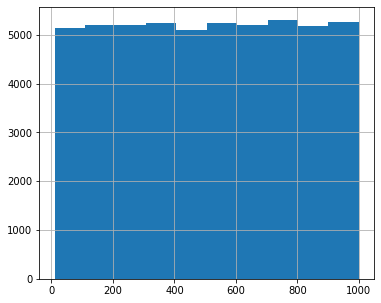

In [48]:
# Построим гистаграмму для таблицы df_products, столбца price

df_products['price'].hist(figsize=(6, 5)) 


<AxesSubplot:>

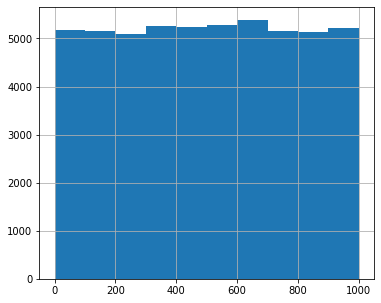

In [49]:
# Построим гистаграмму для таблицы df_products, столбца stock_quantity

df_products['stock_quantity'].hist(figsize=(6, 5)) 


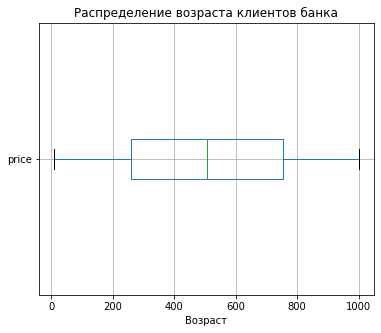

In [50]:
# Строим диаграмму размаха методом boxplot() для таблицы df_products, столбца price
boxplot = df_products.boxplot(column='price',
                     vert=False, 
                     figsize=(6, 5))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение возраста клиентов банка')
boxplot.set_xlabel('Возраст')

plt.show()

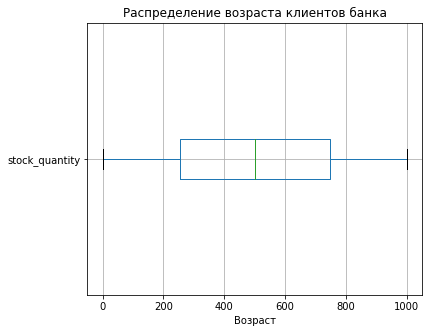

In [51]:
# Строим диаграмму размаха методом boxplot() для таблицы df_products, столбца stock_quantity
boxplot = df_products.boxplot(column='stock_quantity',
                     vert=False, 
                     figsize=(6, 5))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение возраста клиентов банка')
boxplot.set_xlabel('Возраст')

plt.show()

In [74]:
# Считаем и оцениваем корреляцию price и stock_quantity

# Рассчитаем корреляционную матрицу с коэффициентом Пирсона, используя min_periods=3
print("Корреляционная матрица с коэффициентом Пирсона:")
print(df_products[['price', 'stock_quantity']].corr(method='pearson', min_periods=3))

# Рассчитаем корреляционную матрицу с коэффициентом Спирмена, используя min_periods=3
print("\nКорреляционная матрица с коэффициентом Спирмена:")
print(df_products[['price', 'stock_quantity']].corr(method='spearman', min_periods=3))

Корреляционная матрица с коэффициентом Пирсона:
                   price  stock_quantity
price           1.000000        0.000815
stock_quantity  0.000815        1.000000

Корреляционная матрица с коэффициентом Спирмена:
                   price  stock_quantity
price           1.000000        0.000779
stock_quantity  0.000779        1.000000


<AxesSubplot:title={'center':'Зависимость price и stock_quantity'}, xlabel='price', ylabel='stock_quantity'>

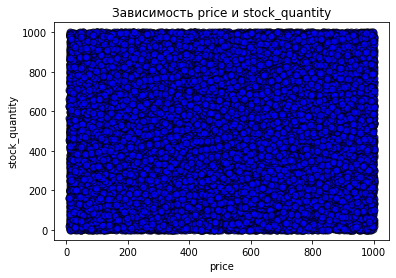

In [73]:
# Визуализируем корреляцию 

df_products.plot(
    kind='scatter',      # Определяет, что тип графика — scatterplot
    x='price',  # Данные по оси X
    y='stock_quantity',  # Данные по оси Y
    alpha=0.7,           # Прозрачность точек
    color='blue',        # Цвет точек
    edgecolor='black',   # Цвет контура точек
    s=50,                # Размер точек
    title='Зависимость price и stock_quantity' # Заголовок графика
) 